<a href="https://colab.research.google.com/github/LIAdrien/projeto-git-uft/blob/main/sprint_2_parte_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1: Arquitetura de Dados · Inteligência Tributária (Sefin Palmas)
**BIINAR · Eixo II 2026/2 · Sprint 2**

Este notebook entrega, de forma visual, a Parte 1: aplicação das estruturas do Módulo 3 ao problema da dívida ativa.

| Seção | O que mostra |
|---|---|
| 1. Simulação | 1000 cidadãos fictícios, 10-25% de ids repetidos, IPTU Social |
| 2. Grafo | Relações id → imóvel/empresa → processo |
| 3. Heap | Fila de cobrança por score de recuperabilidade |
| 4. Tabela hash | Índices da dívida ativa (encadeamento) |
| 5. Big-O | Curvas teóricas, medição empírica e tabela de complexidade |

**Como usar no Colab:** menu *Ambiente de execução → Executar tudo*. Usa só bibliotecas já instaladas no Colab (numpy e matplotlib). Todos os dados são simulados. As imagens são salvas na pasta `imagens/` e a última célula baixa um zip com elas.


In [2]:
# Estruturas e simulação (mesmo código do arquivo parte1_estruturas.py)
"""
SIMULAÇÃO - Sprint 2 / Parte 1 - Inteligência Tributária (Sefin Palmas)
=======================================================================
1000 cidadãos fictícios (id de 7 dígitos, simulando o CPF), com 10-25% de ids
repetidos em mais de um registro (imóvel ou empresa), IPTU Social aplicado
sobre os imóveis e as três estruturas do Módulo 3:
   Grafo (relações) | Tabela Hash (índices) | Heap (fila de cobrança)

Somente biblioteca padrão. Todos os dados são simulados.

Arquivo único da Parte 1. Uso:
    No Colab: execute as células na ordem.
    Fora do Colab: o mesmo código está em parte1_estruturas.py
"""
import heapq
import math
import random
import statistics
import sys
from collections import Counter, defaultdict, deque
from dataclasses import dataclass, replace


# ======================================================================
# 0. CONFIGURAÇÃO  (todos os parâmetros num lugar só)
# ======================================================================
@dataclass(frozen=True)
class Config:
    n_cidadaos: int = 1000
    seed: int = 2026
    # Repetição de ids
    faixa_repetidos: tuple = (0.10, 0.25)   # fração de ids com 2+ registros
    max_registros: int = 5                  # por id
    max_imoveis: int = 2                    # por id
    max_empresas: int = 3                   # por id
    # IPTU Social de Palmas (art. 20 do Código Tributário Municipal)
    limite_automatico_ufip: float = 50      # isenção automática: IPTU < 50 Ufip
    limite_social_ufip: float = 150         # isenção social: IPTU < 150 Ufip
    # Meta pública: 30.304 imóveis isentos / 153.357 imóveis na base (IPTU 2026)
    meta_isentos: float = 30304 / 153357    # ≈ 19,76 %
    tolerancia_isentos: float = 0.04        # ±4 pontos percentuais
    # Distribuição do IPTU em Ufip (lognormal). mu calibrado para a meta.
    mu_iptu: float = 4.61
    sigma_iptu: float = 0.90


# ======================================================================
# 1. MODELO DE DADOS
# ======================================================================
@dataclass
class Cidadao:
    id: int                  # 7 dígitos (simula o CPF)
    idoso: bool              # mais de 65 anos
    aposentado: bool
    pensionista: bool
    incapacitado: bool       # deficiência física incapacitante para o trabalho
    renda_ate_2sm: bool

    @property
    def beneficiario(self) -> bool:
        return self.idoso or self.aposentado or self.pensionista or self.incapacitado


@dataclass
class Registro:
    """Um imóvel ou uma empresa ligada a um cidadão, com sua inscrição em dívida."""
    id: str
    cidadao_id: int
    tipo: str                # "imovel" | "empresa"
    valor: float             # valor da dívida (R$)
    anos_atraso: float
    processo: str | None     # número do processo (só se ajuizada)
    residencial: bool = False
    iptu_ufip: float | None = None
    isento: bool = False
    motivo_isencao: str | None = None

    @property
    def ajuizada(self) -> bool:
        return self.processo is not None


# ======================================================================
# 2. GERAÇÃO DOS DADOS
# ======================================================================
def gerar_cidadaos(cfg, rng):
    ids = rng.sample(range(1_000_000, 10_000_000), cfg.n_cidadaos)   # únicos
    return [Cidadao(id=i,
                    idoso=rng.random() < 0.08,
                    aposentado=rng.random() < 0.07,
                    pensionista=rng.random() < 0.03,
                    incapacitado=rng.random() < 0.02,
                    renda_ate_2sm=rng.random() < 0.50)
            for i in ids]


def planejar_registros(cfg, rng, cidadaos):
    """Define quantos imóveis/empresas cada id terá. Retorna {id: (n_imoveis, n_empresas)}."""
    taxa = rng.uniform(*cfg.faixa_repetidos)
    repetidos = set(rng.sample([c.id for c in cidadaos], round(taxa * len(cidadaos))))
    plano = {}
    for c in cidadaos:
        if c.id in repetidos:                        # 2 a 5 registros
            total = rng.choices([2, 3, 4, 5], weights=[50, 25, 15, 10])[0]
            n_imov = rng.randint(max(0, total - cfg.max_empresas),
                                 min(cfg.max_imoveis, total))
            plano[c.id] = (n_imov, total - n_imov)
        else:                                        # 1 registro
            plano[c.id] = (1, 0) if rng.random() < 0.85 else (0, 1)
    return plano


def gerar_registros(cfg, rng, cidadaos, plano):
    registros = []
    for c in cidadaos:
        n_imov, n_emp = plano[c.id]
        for tipo in ["imovel"] * n_imov + ["empresa"] * n_emp:
            n = len(registros) + 1
            r = Registro(id=f"R-{n:04d}", cidadao_id=c.id, tipo=tipo,
                         valor=round(rng.uniform(300, 45000), 2),
                         anos_atraso=round(rng.uniform(0.5, 9), 1),
                         processo=f"PJ-{n:04d}" if rng.random() < 0.40 else None)
            if tipo == "imovel":
                r.residencial = rng.random() < 0.90
                r.iptu_ufip = round(rng.lognormvariate(cfg.mu_iptu, cfg.sigma_iptu), 1)
            registros.append(r)
    return registros


# ======================================================================
# 3. IPTU SOCIAL  (marca os registros isentos)
# ======================================================================
def aplicar_iptu_social(cfg, cidadaos, registros):
    """
    Regras (art. 20 do CTM de Palmas), aplicadas só a IMÓVEIS:
      - pessoa física, único imóvel no município, uso exclusivamente residencial
      - Automática: IPTU < 50 Ufip
      - Social: (idoso > 65, aposentado, pensionista ou PCD incapacitado)
                + renda até 2 salários mínimos + IPTU < 150 Ufip
    """
    por_id = {c.id: c for c in cidadaos}
    n_imoveis = Counter(r.cidadao_id for r in registros if r.tipo == "imovel")
    for r in registros:
        if r.tipo != "imovel" or not r.residencial or n_imoveis[r.cidadao_id] != 1:
            continue
        c = por_id[r.cidadao_id]
        if r.iptu_ufip < cfg.limite_automatico_ufip:
            r.isento, r.motivo_isencao = True, "automática (< 50 Ufip)"
        elif c.beneficiario and c.renda_ate_2sm and r.iptu_ufip < cfg.limite_social_ufip:
            r.isento, r.motivo_isencao = True, "social (perfil + renda + < 150 Ufip)"


# ======================================================================
# 4. ESTRUTURAS DE DADOS (Módulo 3)
# ======================================================================
class Grafo:
    """Lista de adjacência. Espaço O(V+E); aresta O(1); BFS O(V+E)."""
    def __init__(self):
        self.adj = defaultdict(set)

    def add_aresta(self, a, b):
        self.adj[a].add(b)
        self.adj[b].add(a)

    def componente(self, origem):
        visto, fila = {origem}, deque([origem])
        while fila:
            for v in self.adj[fila.popleft()]:
                if v not in visto:
                    visto.add(v)
                    fila.append(v)
        return visto


class TabelaHash:
    """Encadeamento + rehash (fator de carga 0,75). Busca/inserção O(1) médio, O(n) pior."""
    def __init__(self, capacidade=16):
        self.cap, self.n = capacidade, 0
        self.baldes = [[] for _ in range(capacidade)]

    def _balde(self, chave):
        return self.baldes[hash(chave) % self.cap]

    def _rehash(self):                                   # O(n), amortizado O(1)
        itens = [kv for b in self.baldes for kv in b]
        self.cap *= 2
        self.baldes = [[] for _ in range(self.cap)]
        for k, v in itens:
            self._balde(k).append((k, v))

    def put(self, chave, valor):
        if self.n / self.cap > 0.75:
            self._rehash()
        balde = self._balde(chave)
        for j, (k, _) in enumerate(balde):
            if k == chave:
                balde[j] = (chave, valor)
                return
        balde.append((chave, valor))
        self.n += 1

    def get(self, chave, padrao=None):
        for k, v in self._balde(chave):
            if k == chave:
                return v
        return padrao

    def itens(self):
        return [kv for balde in self.baldes for kv in balde]

    def adicionar(self, chave, valor):
        """Chave com vários valores (ex.: id -> lista de registros)."""
        lista = self.get(chave)
        if lista is None:
            self.put(chave, [valor])
        else:
            lista.append(valor)


class FilaCobranca:
    """Max-heap por score (heapq é min-heap, então guardamos -score).
    Construção O(n) com heapify; pop O(log n); topo O(1)."""
    def __init__(self, itens):                           # itens: [(score, id)]
        self._h = [(-s, i) for s, i in itens]
        heapq.heapify(self._h)

    def pop(self):
        s, i = heapq.heappop(self._h)
        return -s, i

    def melhores(self, k):
        return [(-s, i) for s, i in heapq.nsmallest(k, self._h)]

    def __len__(self):
        return len(self._h)


def score_recuperabilidade(r, qtd_registros_do_id):
    """Heurística SIMULADA (0-100): valor 40% | recência 30% | ajuizada 15% | recorrência 15%."""
    return round(min(r.valor / 45000, 1) * 40
                 + max(0, 1 - r.anos_atraso / 9) * 30
                 + (15 if r.ajuizada else 0)
                 + min(qtd_registros_do_id, 5) / 5 * 15, 1)


@dataclass
class Estruturas:
    grafo: Grafo
    por_registro: TabelaHash     # id do registro -> Registro
    por_cidadao: TabelaHash      # id do cidadão  -> [ids dos registros]
    fila: FilaCobranca           # só registros NÃO isentos


def construir_estruturas(registros):
    """Uma única passagem pelos registros alimenta as três estruturas."""
    est = Estruturas(Grafo(), TabelaHash(), TabelaHash(), None)
    for r in registros:
        est.por_registro.put(r.id, r)
        est.por_cidadao.adicionar(r.cidadao_id, r.id)
        est.grafo.add_aresta(("P", r.cidadao_id), ("R", r.id))
        if r.processo:
            est.grafo.add_aresta(("R", r.id), ("X", r.processo))
    est.fila = FilaCobranca(
        [(score_recuperabilidade(r, len(est.por_cidadao.get(r.cidadao_id))), r.id)
         for r in registros if not r.isento])
    return est


# ======================================================================
# 5. ESTATÍSTICAS E VERIFICAÇÕES
# ======================================================================
def estatisticas(cfg, cidadaos, registros):
    por_id = Counter(r.cidadao_id for r in registros)
    imoveis = [r for r in registros if r.tipo == "imovel"]
    isentos = [r for r in imoveis if r.isento]
    return {
        "cidadaos": len(cidadaos),
        "registros": len(registros),
        "imoveis": len(imoveis),
        "empresas": len(registros) - len(imoveis),
        "ids_repetidos": sum(1 for q in por_id.values() if q >= 2),
        "taxa_ids_repetidos": sum(1 for q in por_id.values() if q >= 2) / len(cidadaos),
        "taxa_registros_repetidos": (len(registros) - len(por_id)) / len(registros),
        "distribuicao": dict(sorted(Counter(por_id.values()).items())),
        "isentos": len(isentos),
        "taxa_isentos": len(isentos) / len(imoveis),
        "isentos_por_motivo": dict(Counter(r.motivo_isencao for r in isentos)),
    }


def verificacoes(cfg, cidadaos, registros, est, stats):
    """Retorna [(nome, passou)]. Não interrompe a execução: cada falha fica visível."""
    ids = [c.id for c in cidadaos]
    por_id = Counter(r.cidadao_id for r in registros)
    imov = Counter(r.cidadao_id for r in registros if r.tipo == "imovel")
    emp = Counter(r.cidadao_id for r in registros if r.tipo == "empresa")
    lo, hi = cfg.faixa_repetidos

    ordem = [est.fila.pop()[0] for _ in range(len(est.fila))]       # esvazia a fila

    th = TabelaHash(2)
    for k in range(100):
        th.put(f"k{k}", k)
    try:
        FilaCobranca([]).pop()
        fila_vazia_ok = False
    except IndexError:
        fila_vazia_ok = True

    return [
        ("ids únicos com 7 dígitos",
         len(set(ids)) == len(ids) and all(1_000_000 <= i <= 9_999_999 for i in ids)),
        ("taxa de ids repetidos entre 10% e 25%",
         lo - 0.005 <= stats["taxa_ids_repetidos"] <= hi + 0.005),
        ("máx. 5 registros, 2 imóveis e 3 empresas por id",
         max(por_id.values()) <= cfg.max_registros
         and max(imov.values(), default=0) <= cfg.max_imoveis
         and max(emp.values(), default=0) <= cfg.max_empresas),
        ("nenhum isento com 2+ imóveis",
         all(imov[r.cidadao_id] == 1 for r in registros if r.isento)),
        ("nenhuma empresa isenta",
         not any(r.isento for r in registros if r.tipo == "empresa")),
        ("% de isentos próximo da meta pública (±4 p.p.)",
         abs(stats["taxa_isentos"] - cfg.meta_isentos) <= cfg.tolerancia_isentos),
        ("hash recupera todos os registros",
         all(est.por_registro.get(r.id) is r for r in registros)),
        ("hash e grafo concordam sobre os registros de cada id",
         all(set(est.por_cidadao.get(i, [])) ==
             {x for t, x in est.grafo.adj[("P", i)] if t == "R"} for i in ids)),
        ("fila só tem não isentos e sai em ordem decrescente",
         len(ordem) == sum(not r.isento for r in registros) and ordem == sorted(ordem, reverse=True)),
        ("rehash preserva 100 chaves", all(th.get(f"k{k}") == k for k in range(100))),
        ("pop em fila vazia levanta IndexError", fila_vazia_ok),
    ]


# ======================================================================
# 7. ANÁLISE DE ERROS (Monte Carlo): roda a simulação com várias sementes
# ======================================================================
def analisar_erros(n_rodadas=500):
    base = Config()
    falhas, desvios, taxas_rep = Counter(), [], []
    rodadas_com_falha = 0
    for seed in range(n_rodadas):
        cfg = replace(base, seed=seed)
        cid, reg, est, s = executar(cfg)
        ruins = [nome for nome, ok in verificacoes(cfg, cid, reg, est, s) if not ok]
        falhas.update(ruins)
        rodadas_com_falha += bool(ruins)
        desvios.append(s["taxa_isentos"] - cfg.meta_isentos)
        taxas_rep.append(s["taxa_ids_repetidos"])

    abs_d = [abs(d) for d in desvios]
    print(f"Rodadas: {n_rodadas}")
    print(f"Rodadas com alguma verificação falha: {rodadas_com_falha} "
          f"({rodadas_com_falha / n_rodadas:.1%})")
    for nome, q in falhas.items():
        print(f"  falha '{nome}': {q} ({q / n_rodadas:.1%})")
    print(f"% isentos: média {statistics.mean(d + base.meta_isentos for d in desvios):.2%} "
          f"| meta {base.meta_isentos:.2%} | desvio-padrão {statistics.pstdev(desvios):.2%}")
    print(f"Erro absoluto médio vs meta: {statistics.mean(abs_d):.2%}")
    print(f"Fora de ±2 p.p.: {sum(d > .02 for d in abs_d) / n_rodadas:.1%} "
          f"| fora de ±4 p.p.: {sum(d > .04 for d in abs_d) / n_rodadas:.1%}")
    print(f"Taxa de ids repetidos: mín {min(taxas_rep):.1%} | "
          f"média {statistics.mean(taxas_rep):.1%} | máx {max(taxas_rep):.1%}")


# ======================================================================
# 6. EXECUÇÃO
# ======================================================================
def executar(cfg=Config()):
    rng = random.Random(cfg.seed)
    cidadaos = gerar_cidadaos(cfg, rng)
    plano = planejar_registros(cfg, rng, cidadaos)
    registros = gerar_registros(cfg, rng, cidadaos, plano)
    aplicar_iptu_social(cfg, cidadaos, registros)
    est = construir_estruturas(registros)
    stats = estatisticas(cfg, cidadaos, registros)
    return cidadaos, registros, est, stats


In [3]:
# Configuração visual (matplotlib + numpy, já instalados no Colab)
import os, time, math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
PASTA = "imagens"
os.makedirs(PASTA, exist_ok=True)

COR = {"pessoa": "#1f3b63", "imovel": "#2a9d8f", "empresa": "#e9a23b",
       "processo": "#8d6cab", "isento": "#c7c7c7", "destaque": "#d1495b"}


def salvar(fig, nome):
    caminho = f"{PASTA}/{nome}.png"
    fig.savefig(caminho, dpi=170, bbox_inches="tight", facecolor="white")
    print("imagem salva:", caminho)


## 1. Simulação
1000 cidadãos com id único de 7 dígitos (simula o CPF). Entre 10% e 25% dos ids se repetem em 2 a 5 registros (até 2 imóveis e 3 empresas por id). O IPTU Social isenta imóveis conforme as regras do art. 20 do Código Tributário de Palmas, calibrado para a meta pública de cerca de 19,76% de imóveis isentos.


In [4]:
cfg = Config()
cidadaos, registros, est, stats = executar(cfg)

print(f"{stats['cidadaos']} cidadãos | {stats['registros']} registros "
      f"({stats['imoveis']} imóveis, {stats['empresas']} empresas)")
print(f"Ids repetidos: {stats['ids_repetidos']} ({stats['taxa_ids_repetidos']:.1%}) "
      f"| registros por id (qtd: ids): {stats['distribuicao']}")
print(f"IPTU Social: {stats['isentos']} de {stats['imoveis']} imóveis isentos "
      f"({stats['taxa_isentos']:.1%}; meta pública {cfg.meta_isentos:.1%})")
print(f"Fila de cobrança: {len(est.fila)} registros (os isentos ficam de fora)")


1000 cidadãos | 1300 registros (904 imóveis, 396 empresas)
Ids repetidos: 162 (16.2%) | registros por id (qtd: ids): {1: 838, 2: 82, 3: 39, 4: 24, 5: 17}
IPTU Social: 182 de 904 imóveis isentos (20.1%; meta pública 19.8%)
Fila de cobrança: 1118 registros (os isentos ficam de fora)


## 2. Grafo: relações id → imóvel/empresa → processo
Cada **id** (círculo azul) liga-se aos seus **registros** (quadrados: imóvel ou empresa) e cada registro ajuizado liga-se ao seu **processo** (losango). A busca em largura (BFS) recupera tudo o que pertence a um id em O(V+E). Imóveis isentos pelo IPTU Social aparecem em cinza.


imagem salva: imagens/grafo.png


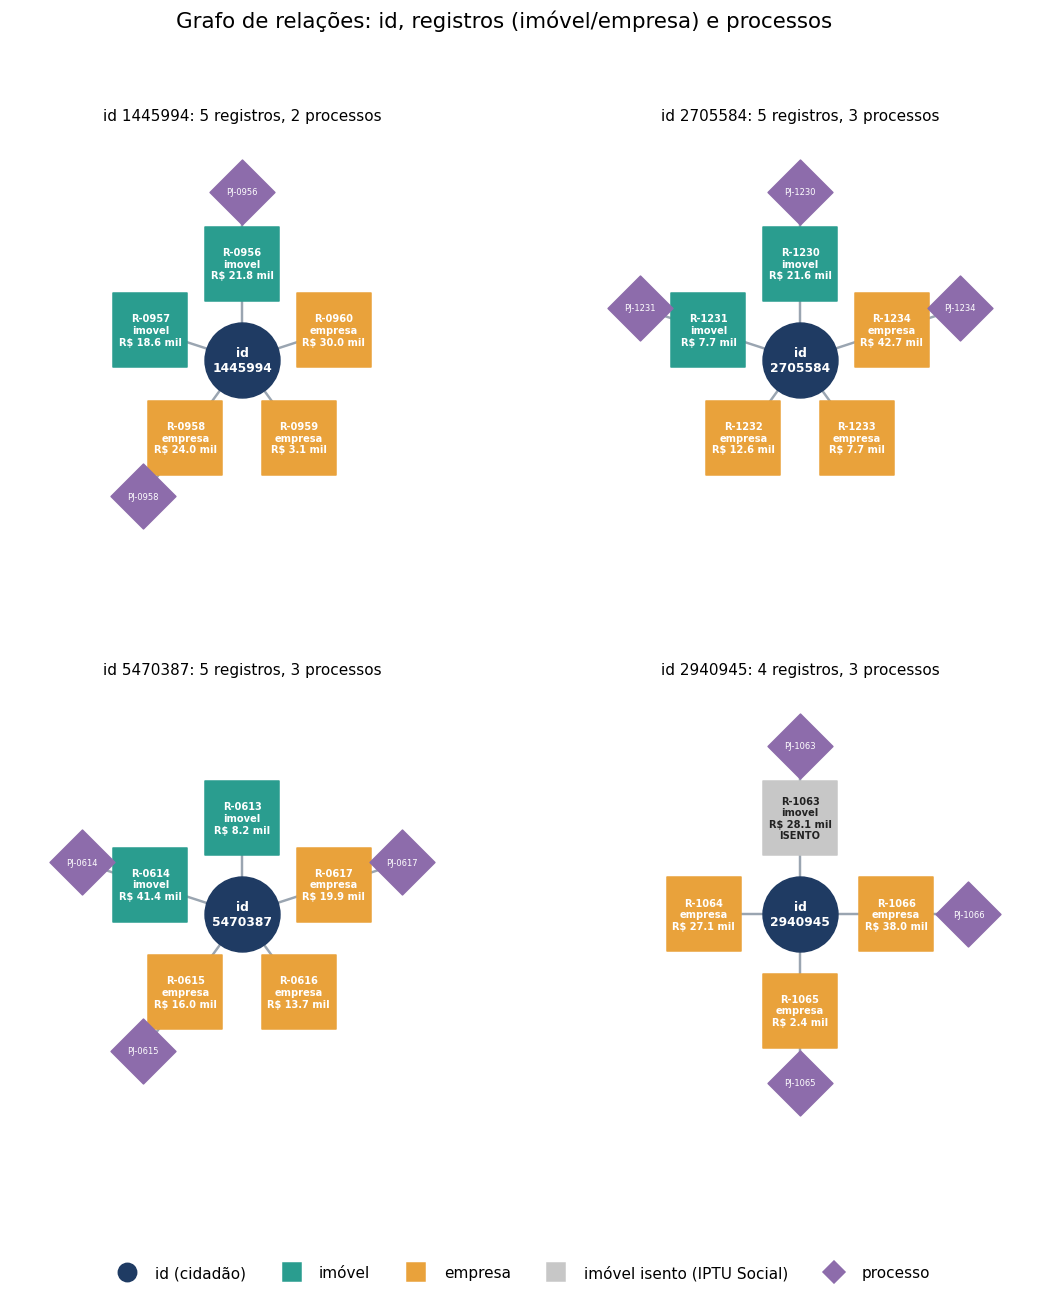

In [5]:
def posicoes_componente(cid, comp):
    """Id no centro; registros em círculo; processos mais para fora, no mesmo ângulo."""
    regs = sorted(x for t, x in comp if t == "R")
    pos = {("P", cid): (0.0, 0.0)}
    for k, rid in enumerate(regs):
        ang = 2 * math.pi * k / len(regs) + math.pi / 2
        pos[("R", rid)] = (math.cos(ang), math.sin(ang))
        proc = est.por_registro.get(rid).processo
        if proc:
            pos[("X", proc)] = (1.75 * math.cos(ang), 1.75 * math.sin(ang))
    return pos


def desenhar_componente(ax, cid):
    comp = est.grafo.componente(("P", cid))
    pos = posicoes_componente(cid, comp)
    for e in {frozenset((a, b)) for a in comp for b in est.grafo.adj[a]}:
        a, b = tuple(e)
        ax.plot(*zip(pos[a], pos[b]), color="#9aa5b1", lw=1.6, zorder=1)
    for (tipo, chave), (x, y) in pos.items():
        if tipo == "P":
            ax.scatter(x, y, s=2400, c=COR["pessoa"], zorder=2)
            ax.text(x, y, f"id\n{chave}", color="white", ha="center", va="center",
                    fontsize=8, fontweight="bold", zorder=3)
        elif tipo == "R":
            r = est.por_registro.get(chave)
            cor = COR["isento"] if r.isento else COR[r.tipo]
            ax.scatter(x, y, s=2300, marker="s", c=cor, zorder=2)
            rotulo = f"{r.id}\n{r.tipo}\nR$ {r.valor / 1000:.1f} mil" + ("\nISENTO" if r.isento else "")
            ax.text(x, y, rotulo, ha="center", va="center", fontsize=6.5, zorder=3,
                    color="#222" if r.isento else "white", fontweight="bold")
        else:
            ax.scatter(x, y, s=900, marker="D", c=COR["processo"], zorder=2)
            ax.text(x, y, chave, ha="center", va="center", fontsize=5.5, color="white", zorder=3)
    n_reg = sum(t == "R" for t, _ in comp)
    n_proc = sum(t == "X" for t, _ in comp)
    ax.set_title(f"id {cid}: {n_reg} registros, {n_proc} processos", fontsize=10)
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.4, 2.4)
    ax.set_aspect("equal"); ax.axis("off")


repetidos = sorted(est.por_cidadao.itens(), key=lambda kv: -len(kv[1]))
escolhidos = [cid for cid, _ in repetidos[:3]]
com_isento = next((c for c, regs in repetidos
                   if len(regs) >= 2 and any(est.por_registro.get(r).isento for r in regs)), None)
if com_isento is not None and com_isento not in escolhidos:
    escolhidos.append(com_isento)

fig, eixos = plt.subplots(2, 2, figsize=(12, 12))
for ax, cid in zip(eixos.flat, escolhidos):
    desenhar_componente(ax, cid)
for ax in list(eixos.flat)[len(escolhidos):]:
    ax.axis("off")
fig.suptitle("Grafo de relações: id, registros (imóvel/empresa) e processos", fontsize=14, y=0.97)
fig.legend(handles=[
    Line2D([], [], marker="o", ls="", ms=12, color=COR["pessoa"], label="id (cidadão)"),
    Line2D([], [], marker="s", ls="", ms=12, color=COR["imovel"], label="imóvel"),
    Line2D([], [], marker="s", ls="", ms=12, color=COR["empresa"], label="empresa"),
    Line2D([], [], marker="s", ls="", ms=12, color=COR["isento"], label="imóvel isento (IPTU Social)"),
    Line2D([], [], marker="D", ls="", ms=10, color=COR["processo"], label="processo")],
    loc="lower center", ncol=5, frameon=False)
salvar(fig, "grafo")
plt.show()


## 3. Heap: fila de cobrança por score de recuperabilidade
O heap guarda só os registros **não isentos**. O score (0-100) combina valor da dívida (40%), recência (30%), processo ativo (15%) e recorrência do id (15%); **esses pesos são suposição da equipe**. Construir o heap custa O(n) (`heapify`); inserir e remover o maior custa O(log n); consultar o topo, O(1). A figura mostra os 15 primeiros nós do vetor interno: cada pai tem score maior ou igual ao dos filhos.


Propriedade do heap verificada em 1118 nós (pai >= filhos).
imagem salva: imagens/heap.png


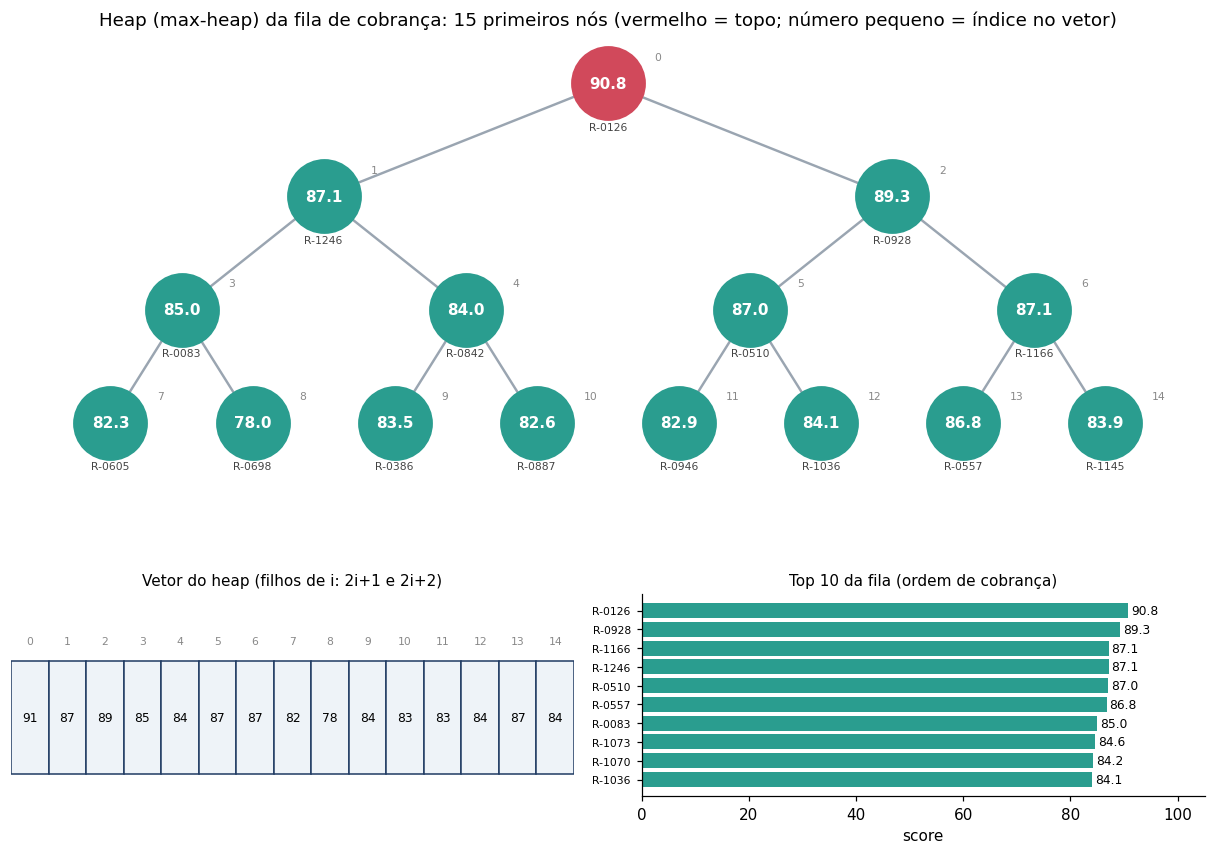

In [6]:
vetor = est.fila._h                       # vetor interno (guarda -score), só para visualizar
assert all(vetor[(i - 1) // 2][0] <= vetor[i][0] for i in range(1, len(vetor))), "propriedade do heap violada"
print(f"Propriedade do heap verificada em {len(vetor)} nós (pai >= filhos).")

N_NOS = 15
nos = vetor[:N_NOS]

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1.3], hspace=0.28, wspace=0.12)

# --- árvore binária ---
ax = fig.add_subplot(gs[0, :])
pos = {}
for i in range(len(nos)):
    nivel = int(math.log2(i + 1))
    k = i - (2 ** nivel - 1)
    pos[i] = ((k + 0.5) * 8 / 2 ** nivel, -nivel * 1.6)
for i in range(1, len(nos)):
    p = (i - 1) // 2
    ax.plot(*zip(pos[p], pos[i]), color="#9aa5b1", lw=1.6, zorder=1)
for i, (neg, rid) in enumerate(nos):
    x, y = pos[i]
    ax.scatter(x, y, s=2300, c=COR["destaque"] if i == 0 else COR["imovel"], zorder=2)
    ax.text(x, y, f"{-neg:.1f}", ha="center", va="center", color="white",
            fontsize=10, fontweight="bold", zorder=3)
    ax.text(x, y - 0.55, rid, ha="center", va="top", fontsize=7, color="#444")
    ax.text(x + 0.33, y + 0.33, str(i), fontsize=7, color="#888")
ax.set_title("Heap (max-heap) da fila de cobrança: 15 primeiros nós "
             "(vermelho = topo; número pequeno = índice no vetor)", fontsize=12)
ax.set_xlim(-0.2, 8.2); ax.set_ylim(-5.9, 0.7); ax.axis("off")

# --- vetor ---
ax2 = fig.add_subplot(gs[1, 0])
for i, (neg, rid) in enumerate(nos):
    ax2.add_patch(Rectangle((i, 0), 1, 1, fc="#eef3f8", ec="#1f3b63"))
    ax2.text(i + .5, .5, f"{-neg:.0f}", ha="center", va="center", fontsize=8)
    ax2.text(i + .5, 1.15, str(i), ha="center", fontsize=7, color="#888")
ax2.set_xlim(0, N_NOS); ax2.set_ylim(-0.2, 1.6); ax2.axis("off")
ax2.set_title("Vetor do heap (filhos de i: 2i+1 e 2i+2)", fontsize=10)

# --- top 10 por ordem de cobrança ---
ax3 = fig.add_subplot(gs[1, 1])
melhores = est.fila.melhores(10)
ax3.barh([rid for _, rid in melhores][::-1], [s for s, _ in melhores][::-1], color=COR["imovel"])
for y, (s, rid) in enumerate(melhores[::-1]):
    ax3.text(s + 0.5, y, f"{s:.1f}", va="center", fontsize=8)
ax3.set_xlim(0, 105); ax3.set_xlabel("score")
ax3.set_title("Top 10 da fila (ordem de cobrança)", fontsize=10)
ax3.tick_params(axis="y", labelsize=7)
salvar(fig, "heap")
plt.show()


## 4. Tabela hash: índices da dívida ativa
Dois índices usam a mesma classe: **id do registro → registro** e **id do cidadão → lista de registros** (o segundo trata os ids repetidos). Colisões são resolvidas por encadeamento; o rehash dobra a capacidade quando o fator de carga passa de 0,75. À esquerda, uma tabela pequena para mostrar o mecanismo (`índice = id mod capacidade`); à direita, a distribuição real das cadeias nos dois índices.


In [ ]:
# --- tabela pequena (demonstração) ---
cid_top = repetidos[0][0]
ids_demo = [cid_top] + [c.id for c in cidadaos if c.id != cid_top][:11]
demo = TabelaHash(capacidade=8)           # cresce para 16 por rehash
for cid in ids_demo:
    demo.put(cid, est.por_cidadao.get(cid))

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.15)

ax = fig.add_subplot(gs[0])
maior = max(len(b) for b in demo.baldes)
for b in range(demo.cap):
    y = demo.cap - 1 - b
    ax.add_patch(Rectangle((0, y - .4), 1.0, .8, fc="#1f3b63", ec="white"))
    ax.text(.5, y, str(b), color="white", ha="center", va="center", fontweight="bold")
    if not demo.baldes[b]:
        ax.text(1.35, y, "vazio", color="#aaa", va="center", fontsize=8)
    for j, (k, v) in enumerate(demo.baldes[b]):
        x = 1.3 + j * 2.1
        destaque = COR["destaque"] if k == cid_top else COR["imovel"]
        ax.add_patch(Rectangle((x, y - .4), 1.8, .8, fc=destaque, ec="white"))
        ax.text(x + .9, y, f"{k}\n{len(v)} reg.", color="white", ha="center",
                va="center", fontsize=7.5, fontweight="bold")
        if j > 0:
            ax.annotate("", xy=(x, y), xytext=(x - .3, y),
                        arrowprops=dict(arrowstyle="->", color="#555"))
ax.set_xlim(-0.2, 1.4 + max(maior, 1) * 2.1); ax.set_ylim(-0.7, demo.cap - 0.3)
ax.axis("off")
ax.set_title(f"Tabela hash com encadeamento: {demo.n} ids, {demo.cap} baldes, "
             f"índice = id mod {demo.cap}\n(vermelho = id mais repetido; reg. = registros do id)", fontsize=11)

# --- distribuição real das cadeias ---
ax2 = fig.add_subplot(gs[1])
def pct_cadeias(th):
    c = Counter(min(len(b), 4) for b in th.baldes)
    return [c.get(k, 0) / th.cap * 100 for k in range(5)]

x = np.arange(5)
for desloc, (nome, th) in zip((-0.2, 0.2), (("id do cidadão", est.por_cidadao), ("id do registro", est.por_registro))):
    ax2.bar(x + desloc, pct_cadeias(th), width=0.4,
            label=f"{nome}: n={th.n}, cap={th.cap}, carga={th.n / th.cap:.2f}")
ax2.set_xticks(x); ax2.set_xticklabels(["0", "1", "2", "3", "4+"])
ax2.set_xlabel("tamanho da cadeia no balde"); ax2.set_ylabel("% dos baldes")
ax2.set_title("Distribuição real das cadeias nos dois índices", fontsize=11)
ax2.legend(fontsize=8, frameon=False)
salvar(fig, "tabela_hash")
plt.show()
print("Maior cadeia (cidadão):", max(len(b) for b in est.por_cidadao.baldes),
      "| (registro):", max(len(b) for b in est.por_registro.baldes))


## 5. Análise de complexidade (Big-O)
Três visões: (a) as **curvas teóricas** e onde cada operação do projeto se encaixa; (b) a **medição empírica** no próprio código, com n de 2 mil a 50 mil; (c) a **tabela resumo** com as alternativas descartadas.


In [ ]:
# (a) Curvas teóricas
n = np.linspace(1, 100, 400)
curvas = [
    (np.ones_like(n),   "O(1): hash (buscar/inserir, caso médio), topo do heap, inserir aresta", "#2a9d8f"),
    (np.log2(n),        "O(log n): push/pop do heap", "#3a86c8"),
    (n,                 "O(n): heapify, rehash, BFS do grafo O(V+E)", "#e9a23b"),
    (n * np.log2(n),    "O(n log n): esvaziar o heap (n pops); n pushes", "#d1495b"),
    (n ** 2 / 20,       "O(n²): pior caso do hash em n inserções; matriz de adjacência (espaço)", "#8d6cab"),
]
fig, ax = plt.subplots(figsize=(11, 6))
for y, rotulo, cor in curvas:
    ax.plot(n, y, lw=2.4, color=cor, label=rotulo)
ax.set_ylim(0, 400); ax.set_xlim(1, 100)
ax.set_xlabel("tamanho da entrada (n)"); ax.set_ylabel("operações (escala relativa)")
ax.set_title("Curvas de crescimento: onde cada operação do projeto se encaixa")
ax.legend(loc="upper left", fontsize=8.5, frameon=False)
ax.text(100, -45, "O(n²) está dividido por 20 só para caber na escala.", ha="right", fontsize=7.5, color="#666")
salvar(fig, "big_o_curvas")
plt.show()


In [ ]:
# (b) Medição empírica: tempo real das nossas classes (pode levar alguns segundos)
def medir(f, repetir=3):
    melhor = float("inf")
    for _ in range(repetir):
        t0 = time.perf_counter(); f()
        melhor = min(melhor, time.perf_counter() - t0)
    return melhor

NS = [2_000, 5_000, 10_000, 20_000, 50_000]
SERIES = {"hash_put": [], "hash_get": [], "heap_build": [], "heap_popall": [],
          "grafo_aresta": [], "grafo_bfs": []}
rng_t = random.Random(1)

for n_ in NS:
    chaves = rng_t.sample(range(1_000_000, 10 ** 8), n_)
    def montar_hash():
        t = TabelaHash()
        for k in chaves: t.put(k, k)
        return t
    SERIES["hash_put"].append(medir(montar_hash))
    th = montar_hash()
    SERIES["hash_get"].append(medir(lambda: [th.get(k) for k in chaves]))

    itens = [(rng_t.random() * 100, i) for i in range(n_)]
    SERIES["heap_build"].append(medir(lambda: FilaCobranca(itens)))
    def esvaziar():
        f = FilaCobranca(itens)
        for _ in range(n_): f.pop()
    SERIES["heap_popall"].append(medir(esvaziar))

    arestas = [(i, i + 1) for i in range(n_ - 1)] + [(i, rng_t.randrange(n_)) for i in range(n_)]
    def montar_grafo():
        g = Grafo()
        for a, b in arestas: g.add_aresta(a, b)
        return g
    SERIES["grafo_aresta"].append(medir(montar_grafo))
    g = montar_grafo()
    SERIES["grafo_bfs"].append(medir(lambda: g.componente(0)))

PAINEIS = [
    ("Tabela hash", [("hash_put", "n inserções (put)"), ("hash_get", "n buscas (get)")]),
    ("Heap", [("heap_build", "construir (heapify)"), ("heap_popall", "esvaziar (n pops)")]),
    ("Grafo", [("grafo_aresta", "n arestas inseridas"), ("grafo_bfs", "BFS (V+E)")]),
]
fig, eixos = plt.subplots(2, 3, figsize=(15, 8))
cores = ["#2a9d8f", "#d1495b"]
print(f"{'série':<14}{'inclinação log-log':>20}   (≈1 → linear; um pouco acima de 1 → n log n)")
for col, (titulo, series) in enumerate(PAINEIS):
    for (chave, rotulo), cor in zip(series, cores):
        t = np.array(SERIES[chave])
        incl = np.polyfit(np.log(NS), np.log(t), 1)[0]
        print(f"{chave:<14}{incl:>20.2f}")
        eixos[0, col].loglog(NS, t, "o-", color=cor, label=f"{rotulo} (incl. {incl:.2f})")
        eixos[1, col].semilogx(NS, t / np.array(NS) * 1e6, "o-", color=cor, label=rotulo)
    eixos[0, col].set_title(f"{titulo}: tempo total para n operações")
    eixos[0, col].set_xlabel("n"); eixos[0, col].set_ylabel("segundos")
    eixos[0, col].legend(fontsize=8, frameon=False)
    eixos[1, col].set_title(f"{titulo}: tempo por operação")
    eixos[1, col].set_xlabel("n"); eixos[1, col].set_ylabel("microssegundos por operação")
    eixos[1, col].set_ylim(bottom=0); eixos[1, col].legend(fontsize=8, frameon=False)
fig.suptitle("Medição empírica: total ≈ linear e custo por operação ≈ constante "
             "(hash, heapify, arestas, BFS); o pop do heap cresce devagar (log n)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
salvar(fig, "big_o_medicao")
plt.show()


In [ ]:
# (c) Tabela resumo de complexidade
LINHAS = [
    ("Grafo (lista de adjacência)", "Inserir aresta", "O(1)", "O(1)", "Matriz de adjacência: espaço O(V²)"),
    ("Grafo (lista de adjacência)", "BFS do componente", "O(V+E)", "O(V+E)", "—"),
    ("Grafo (lista de adjacência)", "Espaço", "O(V+E)", "O(V+E)", "Matriz de adjacência: O(V²)"),
    ("Tabela hash (encadeamento)", "Inserir / buscar", "O(1)", "O(n)", "Lista: busca O(n); vetor ordenado: inserção O(n)"),
    ("Tabela hash (encadeamento)", "Rehash", "O(n), amortizado O(1)", "O(n)", "—"),
    ("Heap (fila de cobrança)", "Construir (heapify)", "O(n)", "O(n)", "n pushes: O(n log n)"),
    ("Heap (fila de cobrança)", "Push / pop", "O(log n)", "O(log n)", "Lista ordenada: inserção O(n)"),
    ("Heap (fila de cobrança)", "Topo", "O(1)", "O(1)", "—"),
    ("Heap (fila de cobrança)", "k melhores sem remover", "O(n log k)", "O(n log k)", "—"),
]
TINTA = {"Grafo": "#e3f1f0", "Tabela": "#fdf1dc", "Heap": "#f7e1e4"}
fig, ax = plt.subplots(figsize=(14, 5.2))
ax.axis("off")
tabela = ax.table(cellText=LINHAS,
                  colLabels=["Estrutura", "Operação", "Caso médio", "Pior caso", "Alternativa descartada e seu custo"],
                  colWidths=[0.2, 0.17, 0.16, 0.1, 0.37], loc="center", cellLoc="left")
tabela.auto_set_font_size(False); tabela.set_fontsize(9); tabela.scale(1, 1.9)
for (lin, col), celula in tabela.get_celld().items():
    celula.set_edgecolor("white")
    if lin == 0:
        celula.set_facecolor("#1f3b63"); celula.get_text().set_color("white"); celula.get_text().set_weight("bold")
    else:
        celula.set_facecolor(TINTA[LINHAS[lin - 1][0].split()[0]])
ax.set_title("Resumo de complexidade das estruturas da Parte 1", fontsize=13, pad=12)
salvar(fig, "big_o_tabela")
plt.show()


## 6. Verificações e download das imagens
As 11 verificações confirmam as regras da simulação (7 dígitos, 10-25% de repetição, limites por id, regras do IPTU Social, hash, grafo e heap). A última célula compacta as imagens para download.


In [ ]:
resultados = verificacoes(cfg, cidadaos, registros, est, stats)   # esvazia a fila: rode por último
for nome, ok in resultados:
    print(f" {'ok   ' if ok else 'FALHA'} - {nome}")
print(f"\n{sum(ok for _, ok in resultados)}/{len(resultados)} verificações passaram.")


In [ ]:
import shutil
shutil.make_archive("imagens_parte1", "zip", PASTA)
print("arquivo criado: imagens_parte1.zip", sorted(os.listdir(PASTA)))
try:
    from google.colab import files
    files.download("imagens_parte1.zip")
except ImportError:
    print("(fora do Colab: o zip e a pasta 'imagens/' estão na pasta atual)")
